# 📈 ➕ 📉 Multiple Linear Regression Model :- Predicting sales based on advertising on TV, Radio, Newspaper

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [2]:
import pandas as pd
data = pd.read_csv('advertising.csv')
# Display the first few rows of the dataset
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
data.shape

(200, 4)

In [4]:
data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

## Define the independent variable(x) and dependent variable(y)

In [5]:
x= data[['TV', 'Radio','Newspaper']] # predictors
y=data.Sales # target value

In [6]:
x.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [7]:
y.head()

0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64

Text(0, 0.5, 'Sales')

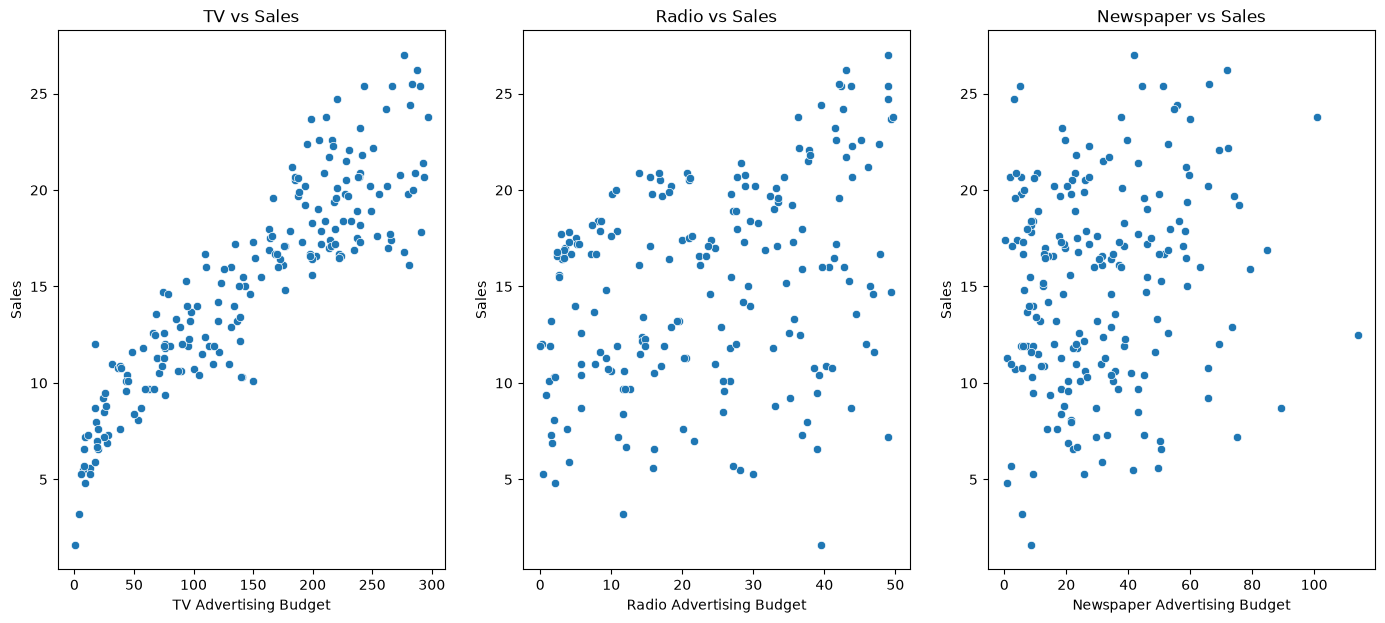

In [8]:
# Plotting scatter plot

plt.figure(figsize=(17,7))

# Scatter plot for TV vs Sales
plt.subplot(1,3,1)
sns.scatterplot(x=data.TV,y=data.Sales)
plt.title('TV vs Sales')
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')

# Scatter plot for Radio vs Sales
plt.subplot(1,3,2)
sns.scatterplot(x=data.Radio,y=data.Sales)
plt.title('Radio vs Sales')
plt.xlabel('Radio Advertising Budget')
plt.ylabel('Sales')

# Scatter plot for Newspaper vs Sales
plt.subplot(1,3,3)
sns.scatterplot(x=data.Newspaper,y=data.Sales)
plt.title('Newspaper vs Sales')
plt.xlabel('Newspaper Advertising Budget')
plt.ylabel('Sales')

In [9]:
# Check if any predictor(x) is corelated to another predictor
x.corr()

,TV,Radio,Newspaper
TV,1.000000,0.054809,0.056648
Radio,0.054809,1.000000,0.354104
Newspaper,0.056648,0.354104,1.000000


## Compute the correlation matrix

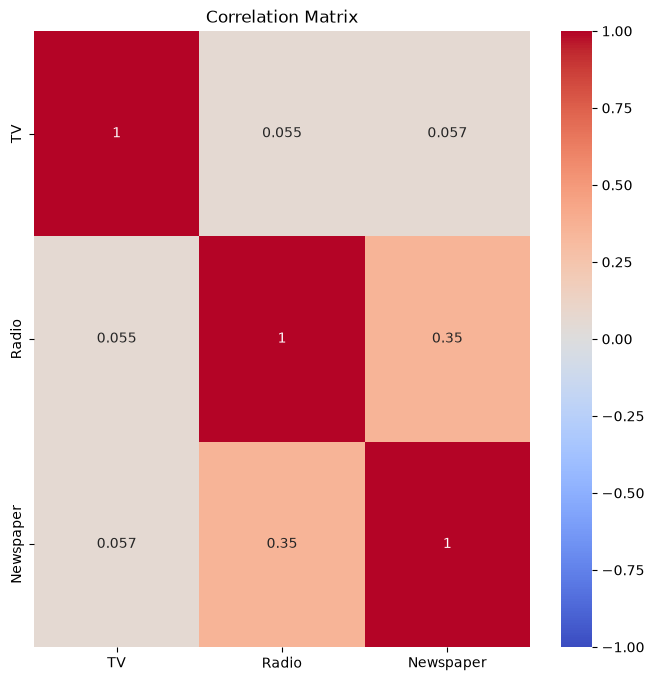

                 TV     Radio  Newspaper
TV         1.000000  0.054809   0.056648
Radio      0.054809  1.000000   0.354104
Newspaper  0.056648  0.354104   1.000000


In [10]:
correlation_matrix = x.corr()

# Plot the correlation matrix
plt.figure(figsize=(8,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1)
plt.title('Correlation Matrix')
plt.show()

print(correlation_matrix)

## VIF Variance Inflation Factor

In [11]:
x.columns

Index(['TV', 'Radio', 'Newspaper'], dtype='str')

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate the VIF for each feature
vif_data = pd.DataFrame()
vif_data

""


In [13]:
vif_data["feature"] = x.columns
vif_data

,feature
0,TV
1,Radio
2,Newspaper


In [14]:
vif_data["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

print("Variance Inflation Factors (VIF):")
print(vif_data)

Variance Inflation Factors (VIF):
     feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


## Split the data into training and testing sets

In [15]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [18]:
x_train.head()

,TV,Radio,Newspaper
169,284.3,10.6,6.4
97,184.9,21.0,22.0
31,112.9,17.4,38.6
12,23.8,35.1,65.9
35,290.7,4.1,8.5


In [19]:
x_train.shape

(140, 3)

In [20]:
y_train.shape

(140,)

In [21]:
x_test.shape , y_test.shape

((60, 3), (60,))

In [23]:
y_train.head()

169    20.0
97     20.5
31     11.9
12      9.2
35     17.8
Name: Sales, dtype: float64

## Create and Train the LM model

In [22]:
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Make Predictions

In [26]:
y_test_pred = linear_model.predict(x_test)

In [27]:
y_test_pred

array([17.15991908, 20.53369503, 23.68914396,  9.5191455 , 21.60736836,
       12.78101318, 21.08636345,  8.76054246, 17.11499951, 16.68789636,
        8.97584663,  8.57645026, 18.33212325,  8.17863567, 12.64605571,
       14.94486946,  8.34939536, 17.83858948, 11.12172174, 20.37740648,
       20.9483297 , 13.04035779, 11.01360656, 22.51142595,  9.40369784,
        7.98591291, 20.86943368, 13.77882255, 10.83407064,  8.00419229,
       15.88597618, 10.7027424 , 20.9521718 , 10.84679243, 21.50720813,
       21.07347295, 12.22673775, 22.85273767, 12.57698182,  6.54597206,
       11.93411853, 15.23490068, 10.07411153,  9.52159696, 17.11786382,
        7.28032677, 10.49404864, 15.24356754, 11.20742176, 11.78392665,
       14.01472163, 14.59884572, 10.82722434,  9.55839415,  9.03749681,
       12.51183313, 10.52551021, 25.01900824,  7.99334943, 15.73916263])

In [30]:
y_test.head()

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
Name: Sales, dtype: float64

In [31]:
### Create DataFrame for testing data

test_results = pd.DataFrame({
    'Original Sales (Test)': y_test,
    'Predicted Sales (Test)': y_test_pred
})

# Display the first few rows of the testing results
print("Testing Data Results:")
print(test_results.head())

Testing Data Results:
     Original Sales (Test)  Predicted Sales (Test)
95                    16.9               17.159919
15                    22.4               20.533695
30                    21.4               23.689144
158                    7.3                9.519146
128                   24.7               21.607368
